In [4]:
!pip install einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.5 MB/s eta 0:00:00


In [ ]:
torch.min(torch.tensor([1, 2, 3]), torch.tensor([4, 1, 5]))

tensor([1, 1, 3])

In [5]:
from torch.autograd import Function
import torch.nn.functional as F
import torch.nn as nn
import torch
import numpy as np
import einops


def fantastic_four(conv_filter, num_iters=50, device="cuda"):
    groups, out_ch, in_ch, h, w = conv_filter.shape

    u1 = torch.randn((groups, 1, in_ch, 1, w), device=device, requires_grad=False)
    u1.data = l2_normalize(u1.data)

    u2 = torch.randn((groups, 1, in_ch, h, 1), device=device, requires_grad=False)
    u2.data = l2_normalize(u2.data)

    u3 = torch.randn((groups, 1, in_ch, h, w), device=device, requires_grad=False)
    u3.data = l2_normalize(u3.data)

    u4 = torch.randn((groups, out_ch, 1, h, w), device=device, requires_grad=False)
    u4.data = l2_normalize(u4.data)

    v1 = torch.randn((groups, out_ch, 1, h, 1), device=device, requires_grad=False)
    v1.data = l2_normalize(v1.data)

    v2 = torch.randn((groups, out_ch, 1, 1, w), device=device, requires_grad=False)
    v2.data = l2_normalize(v2.data)

    v3 = torch.randn((groups, out_ch, 1, 1, 1), device=device, requires_grad=False)
    v3.data = l2_normalize(v3.data)

    v4 = torch.randn((groups, 1, in_ch, 1, 1), device=device, requires_grad=False)
    v4.data = l2_normalize(v4.data)

    for i in range(num_iters):
        v1.data = l2_normalize(
            (conv_filter.data * u1.data).sum((2, 4), keepdim=True).data
        )
        u1.data = l2_normalize(
            (conv_filter.data * v1.data).sum((1, 3), keepdim=True).data
        )

        v2.data = l2_normalize(
            (conv_filter.data * u2.data).sum((2, 3), keepdim=True).data
        )
        u2.data = l2_normalize(
            (conv_filter.data * v2.data).sum((1, 4), keepdim=True).data
        )

        v3.data = l2_normalize(
            (conv_filter.data * u3.data).sum((2, 3, 4), keepdim=True).data
        )
        u3.data = l2_normalize((conv_filter.data * v3.data).sum(1, keepdim=True).data)

        v4.data = l2_normalize(
            (conv_filter.data * u4.data).sum((1, 3, 4), keepdim=True).data
        )
        u4.data = l2_normalize((conv_filter.data * v4.data).sum(2, keepdim=True).data)

    return u1, v1, u2, v2, u3, v3, u4, v4


def l2_normalize(tensor, eps=1e-12):
    norm = torch.sqrt(torch.sum(tensor.float() * tensor.float(), dim=0))
    norm = torch.max(norm, torch.tensor([eps], device=norm.device))
    ans = tensor / norm
    return ans


def transpose_filter(conv_filter):
    conv_filter_T = torch.transpose(conv_filter, 1, 2)
    conv_filter_T = torch.flip(conv_filter_T, [3, 4])
    return conv_filter_T


class SOC_Function(Function):
    @staticmethod
    def forward(ctx, curr_z, conv_filter):
        ctx.conv_filter = conv_filter
        n_groups = conv_filter.shape[0] // conv_filter.shape[1]
        ctx.n_groups = n_groups
        kernel_size = conv_filter.shape[2]
        z = curr_z
        for i in range(1, 14):
            curr_z = F.conv2d(
                curr_z, conv_filter, padding=(kernel_size // 2, kernel_size // 2), groups=n_groups
            ) / float(i)
            z = z + curr_z
        return z

    @staticmethod
    def backward(ctx, grad_output):
        conv_filter = ctx.conv_filter
        n_groups = ctx.n_groups
        kernel_size = conv_filter.shape[2]
        grad_input = grad_output
        for i in range(1, 14):
            grad_output = F.conv2d(
                grad_output, -conv_filter, padding=(kernel_size // 2, kernel_size // 2), groups=n_groups
            ) / float(i)
            grad_input = grad_input + grad_output

        return grad_input, None


class SOC(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=None,
        bias=True,
        groups=1,
        train_terms=5,
        eval_terms=12,
        init_iters=50,
        update_iters=1,
        update_freq=200,
        correction=0.7,
        device="cuda",
        testing=False
    ):
        super(SOC, self).__init__()
        assert (stride == 1) or (stride == 2)
        self.init_iters = init_iters
        self.out_channels = out_channels
        self.in_channels = in_channels * stride * stride
        self.groups = groups
        assert max(self.out_channels, self.in_channels) % self.groups == 0
        self.max_channels = max(self.out_channels, self.in_channels) // self.groups
        self.device = device
        self.stride = stride
        self.kernel_size = kernel_size
        self.update_iters = update_iters
        self.update_freq = update_freq
        self.total_iters = 0
        self.train_terms = train_terms
        self.eval_terms = eval_terms
        self.testing = testing

        if kernel_size == 1:
            correction = 1.0

        self.random_conv_filter = nn.Parameter(
            torch.randn(
                self.groups,
                self.max_channels,
                self.max_channels,
                self.kernel_size,
                self.kernel_size,
                device=self.device
            ),
            requires_grad=True,
        )
        random_conv_filter_T = transpose_filter(self.random_conv_filter)
        conv_filter = 0.5 * (self.random_conv_filter - random_conv_filter_T)

        with torch.no_grad():
            u1, v1, u2, v2, u3, v3, u4, v4 = fantastic_four(
                conv_filter, num_iters=self.init_iters, device=self.device
            )
            self.u1 = nn.Parameter(u1, requires_grad=False)
            self.v1 = nn.Parameter(v1, requires_grad=False)
            self.u2 = nn.Parameter(u2, requires_grad=False)
            self.v2 = nn.Parameter(v2, requires_grad=False)
            self.u3 = nn.Parameter(u3, requires_grad=False)
            self.v3 = nn.Parameter(v3, requires_grad=False)
            self.u4 = nn.Parameter(u4, requires_grad=False)
            self.v4 = nn.Parameter(v4, requires_grad=False)

        self.correction = nn.Parameter(
            torch.tensor([correction], device=self.device), requires_grad=False
        )

        self.enable_bias = bias
        if self.enable_bias:
            self.bias = nn.Parameter(
                torch.randn(self.out_channels, device=self.device), requires_grad=True
            )
        else:
            self.bias = None
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1.0 / np.sqrt(self.max_channels)
        nn.init.normal_(self.random_conv_filter, std=stdv)

        stdv = 1.0 / np.sqrt(self.out_channels)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def update_sigma(self):
        if self.training:
            if self.total_iters % self.update_freq == 0:
                update_iters = self.init_iters
            else:
                update_iters = self.update_iters
            self.total_iters = self.total_iters + 1
        else:
            update_iters = 0

        random_conv_filter_T = transpose_filter(self.random_conv_filter)
        conv_filter = 0.5 * (self.random_conv_filter - random_conv_filter_T)
        # pad_size = conv_filter.shape[2] // 2
        with torch.no_grad():
            for i in range(update_iters):
                self.v1.data = l2_normalize(
                    (conv_filter * self.u1).sum((2, 4), keepdim=True).data
                )
                self.u1.data = l2_normalize(
                    (conv_filter * self.v1).sum((1, 3), keepdim=True).data
                )
                self.v2.data = l2_normalize(
                    (conv_filter * self.u2).sum((2, 3), keepdim=True).data
                )
                self.u2.data = l2_normalize(
                    (conv_filter * self.v2).sum((1, 4), keepdim=True).data
                )
                self.v3.data = l2_normalize(
                    (conv_filter * self.u3).sum((2, 3, 4), keepdim=True).data
                )
                self.u3.data = l2_normalize(
                    (conv_filter * self.v3).sum(1, keepdim=True).data
                )
                self.v4.data = l2_normalize(
                    (conv_filter * self.u4).sum((1, 3, 4), keepdim=True).data
                )
                self.u4.data = l2_normalize(
                    (conv_filter * self.v4).sum(2, keepdim=True).data
                )

        func = torch.min
        # add sum by dimension because we deal with 5-dimensional tensor and we want
        # to compute approximation for each group separately
        sigma1 = torch.sum(conv_filter * self.u1 * self.v1)
        sigma2 = torch.sum(conv_filter * self.u2 * self.v2)
        sigma3 = torch.sum(conv_filter * self.u3 * self.v3)
        sigma4 = torch.sum(conv_filter * self.u4 * self.v4)
        sigma = func(func(func(sigma1, sigma2), sigma3), sigma4)
        return sigma

    def forward(self, x):
        random_conv_filter_T = transpose_filter(self.random_conv_filter)
        conv_filter_skew = 0.5 * (self.random_conv_filter - random_conv_filter_T)
        sigma = self.update_sigma()
        conv_filter_n = ((self.correction * conv_filter_skew) / sigma).view(
            self.groups * self.max_channels,
            self.max_channels,
            self.kernel_size,
            self.kernel_size,
        )  # add here 1e-12 to sigma to avoid zero division
        if self.training:
            num_terms = self.train_terms
        else:
            num_terms = self.eval_terms

        if self.stride > 1:
            x = einops.rearrange(
                x,
                "b c (w k1) (h k2) -> b (c k1 k2) w h",
                k1=self.stride,
                k2=self.stride,
            )

        if self.out_channels > self.in_channels:
            diff_channels = self.out_channels - self.in_channels
            p4d = (0, 0, 0, 0, 0, diff_channels, 0, 0)
            curr_z = F.pad(x, p4d)
        else:
            curr_z = x

        z = curr_z
        for i in range(1, num_terms + 1):
            curr_z = F.conv2d(
                curr_z,
                conv_filter_n,
                padding=(self.kernel_size // 2, self.kernel_size // 2),
                groups=self.groups,
            ) / float(i)
            z = z + curr_z

        if self.out_channels < self.in_channels:
            z = z[:, :self.out_channels, :, :]

        if self.enable_bias:
            z = z + self.bias.view(1, -1, 1, 1)
        if not self.testing:
            return z
        return z, conv_filter_n


# https://github.com/jaxony/ShuffleNet/blob/e9bf42f0cda8dda518cafffd515654cc04584e7a/model.py#L36C1-L53C13
def channel_shuffle(x, groups):
    batchsize, num_channels, height, width = x.data.size()

    channels_per_group = num_channels // groups

    # reshape
    x = x.view(batchsize, groups, channels_per_group, height, width)

    # transpose
    # - contiguous() required if transpose() is used before view().
    #   See https://github.com/pytorch/pytorch/issues/764
    x = torch.transpose(x, 1, 2).contiguous()

    # flatten
    x = x.view(batchsize, -1, height, width)

    return x


class MonarchSOC(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=None,
        bias=True,
        groups=1,
        train_terms=5,
        eval_terms=12,
        init_iters=50,
        update_iters=1,
        update_freq=200,
        correction=0.7,
        device="cuda",
        testing=False
    ):
        super(MonarchSOC, self).__init__()

        self.soc1 = SOC(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=bias,
            groups=groups,
            train_terms=train_terms,
            eval_terms=eval_terms,
            init_iters=init_iters,
            update_iters=update_iters,
            update_freq=update_freq,
            correction=correction,
            device=device,
            testing=testing
        )

        self.soc2 = SOC(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=bias,
            groups=groups,
            train_terms=train_terms,
            eval_terms=eval_terms,
            init_iters=init_iters,
            update_iters=update_iters,
            update_freq=update_freq,
            correction=correction,
            device=device,
            testing=testing
        )
        self.groups = groups
        self.testing = testing

    def forward(self, x):
        x, filter_1 = self.soc1(x)
        x = channel_shuffle(x, self.groups)
        if not self.testing:
            return self.soc2(x)
        result, filter_2 = self.soc2(x)  # for testing
        return result, filter_1, filter_2


In [42]:
from torch import nn as nn
import torch.utils.benchmark as benchmark

def warmup():
    linear = nn.Linear(10000, 512, device="cuda")
    x = torch.randn(64, 10000, device="cuda")
    t0 = benchmark.Timer(stmt="linear(x)", globals={"x": x, "linear": linear})
    res = t0.timeit(1000).mean
    del x
    del linear
    torch.cuda.empty_cache()

def bench(layer, input):
    warmup()
    t0 = benchmark.Timer(stmt="linear(x)", globals={"x": input, "linear": layer})
    return t0.timeit(100).mean

In [45]:
import matplotlib.pyplot as plt

def plot_bench(batch, in_channels, out_channels, kernel_size, h, w, stride=1):
    n_groups = [1, 2, 4, 8, 16, 32]
    mon_soc_times = []
    basic_soc_times = []
    for groups in n_groups:
        mon_soc = MonarchSOC(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            groups=groups,
            stride=stride
        ).cuda()
        basic_soc = SOC(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            groups=1,
            stride=stride
        ).cuda()
        input = torch.randn(batch, in_channels, h, w).cuda()
        basic_soc_times.append(bench(basic_soc, input))
        del basic_soc
        torch.cuda.empty_cache()
        mon_soc_times.append(bench(mon_soc, input))
        del mon_soc
        torch.cuda.empty_cache()

    plt.plot(n_groups, mon_soc_times, label="monarch_soc")
    plt.plot(n_groups, basic_soc_times, label="basic_soc")
    plt.xlabel("number of groups")
    plt.ylabel("time")
    plt.title(f"batch={batch}, in_ch={in_channels}, out_ch={out_channels}, kernel_size={kernel_size}, h={h}, w={w}")
    plt.legend()
    plt.show()

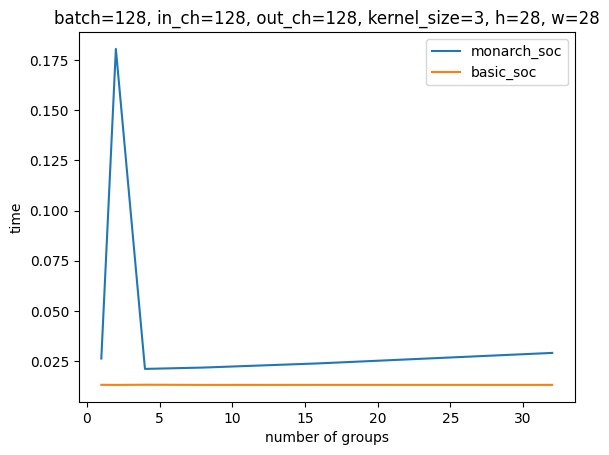

In [46]:
plot_bench(128, 128, 128, 3, 28, 28)

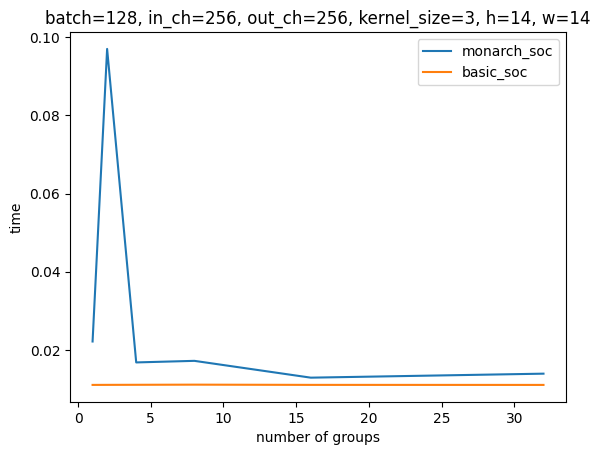

In [47]:
plot_bench(128, 256, 256, 3, 14, 14)

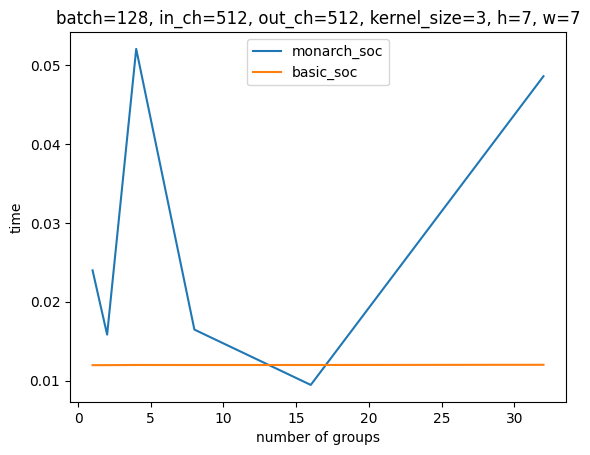

In [48]:
plot_bench(128, 512, 512, 3, 7, 7)

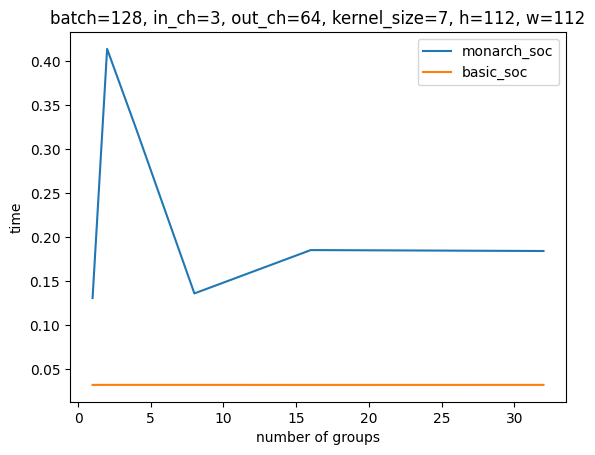

In [49]:
plot_bench(128, 3, 64, 7, 112, 112, stride=2)

In [27]:
mon_soc = MonarchSOC(
    in_channels=128,
    out_channels=128,
    kernel_size=3,
    groups=16
).cuda()
x = torch.randn(128, 128, 28, 28).cuda()

In [28]:
import torch
from torch.profiler import ProfilerActivity, profile, record_function

In [29]:
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
    with record_function("model_inference"):
        mon_soc(x)

STAGE:2024-04-11 09:33:03 34:34 ActivityProfilerController.cpp:312] Completed Stage: Warm Up
STAGE:2024-04-11 09:33:03 34:34 ActivityProfilerController.cpp:318] Completed Stage: Collection
STAGE:2024-04-11 09:33:03 34:34 ActivityProfilerController.cpp:322] Completed Stage: Post Processing


In [30]:
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference        26.39%      75.819ms        97.06%     278.851ms     278.851ms       0.000us         0.00%      44.895ms      44.895ms             1  
                                           aten::conv2d         0.02%      54.000us         1.19%       3.413ms     341.300us       0.000us         0.00%      24.238ms       2.424ms            10  
         

In [31]:
soc = SOC(
    in_channels=128,
    out_channels=128,
    kernel_size=3,
    groups=1
).cuda()
x = torch.randn(128, 128, 28, 28).cuda()

In [32]:
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof_soc:
    with record_function("model_inference"):
        soc(x)

STAGE:2024-04-11 09:33:37 34:34 ActivityProfilerController.cpp:312] Completed Stage: Warm Up
STAGE:2024-04-11 09:33:37 34:34 ActivityProfilerController.cpp:318] Completed Stage: Collection
STAGE:2024-04-11 09:33:37 34:34 ActivityProfilerController.cpp:322] Completed Stage: Post Processing


In [33]:
print(prof_soc.key_averages().table(sort_by="cuda_time_total", row_limit=20))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                        model_inference        26.51%      35.215ms        91.93%     122.107ms     122.107ms       0.000us         0.00%      22.633ms      22.633ms             1  
                                           aten::conv2d         0.02%      31.000us         0.65%     867.000us     173.400us       0.000us         0.00%       9.431ms       1.886ms             5  
         

In [55]:
conv = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3).cuda()
group_conv = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, groups=16).cuda()
x = torch.randn(128, 128, 28, 28).cuda()

In [56]:
warmup()
print(bench(conv, x))
del conv
torch.cuda.empty_cache()
print(bench(group_conv, x))

0.001913472589999401
0.001442848739998226
